# Sentimento de mercado e volatilidade do Bitcoin

Objetivo: Quais features do sentimento de mercado ajuda a **explicar** ou a **prever** a volatilidade do Bitcoin? Para responder, cruzei os índices de sentimento com a volatilidade diária do BTC.

## Os dados

- **Volatilidade diária (`Vol`)** - Cálculo da voltatilidade realizada do Bitcoin
- **Sentimento (MarketPsych)** — índices de sentimento

O maior desafio que tive foi:
 - Os dois têm granularidades diferentes (um é diário, o outro é sub-diário)
 - O sentimento está cheio de buracos

## Roteiro

1. **Etapa 1 - Agregação:** resumo o sentimento sub-diário em um valor por dia
2. **Etapa 2 - Alinhamento:** ligo o sentimento de hoje à volatilidade de amanhã
3. **Etapa 3 - Dados faltantes:** corto colunas muito vazias e preencho o resto com ffill
4. **Etapa 4 - Exploração:** distribuição do alvo, correlações e PCA.
5. **Etapa 5 - Modelo:** Random Forest para ver quais features pesam.

Em todo o estudo comparo duas situações: **contemporânea** (sentimento de hoje × volatilidade de hoje, "explica") e **preditiva** (sentimento de hoje × volatilidade de amanhã, "prevê").

In [1]:
import sys
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score
from scipy.stats import spearmanr

import matplotlib.pyplot as plt

# Adiciona o diretório src ao path de forma mais robusta
sys.path.insert(0, '../')

from src import RepositorioDados, calcular_metricas_regressao

# Load the dataset
sent = pd.read_excel('../data/raw/DadosSentimentoBTC.xlsx')
# Normaliza para datetime sem timezone (datetime64[ns]), compatível com o btc
sent['timestamp'] = pd.to_datetime(sent["windowTimestamp"], utc=True, errors="raise").dt.tz_localize(None)
sent.drop(columns=["windowTimestamp"], inplace=True)

sent.head()

c:\Users\Andre\OneDrive\Documentos\Github\iniciacao-cientifica\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,mentions,buzz,sentiment,negative,positive,optimism,pessimism,joy,loveHate,trust,...,majorityAttack,noobs,regulatoryCrackdown,regulatoryIssues,scam,transactionSpeed,vulnerability,partnership,futureVsPast,timestamp
0,357,2045.9,0.107288,0.184027,0.291314,0.067452,0.022973,0.008309,0.002933,0.015397,...,NaN,NaN,0.001222,0.022484,0.000489,NaN,0.000489,NaN,-0.235789,2017-01-01 20:30:00
1,29,30.2,0.099338,0.165563,0.264901,NaN,NaN,NaN,NaN,-0.033113,...,NaN,NaN,NaN,0.066225,NaN,NaN,NaN,NaN,-0.172185,2017-01-01 20:30:00
2,1010,2890.9,0.135425,0.172784,0.308209,0.077139,0.025425,0.009340,0.003286,0.014355,...,NaN,NaN,0.000865,0.015912,0.000692,NaN,0.000519,NaN,-0.194472,2017-01-01 20:30:00
3,653,845.0,0.203550,0.145562,0.349112,0.100592,0.031361,0.011834,0.004142,0.011834,...,NaN,NaN,NaN,NaN,0.001183,NaN,0.000592,NaN,-0.094438,2017-01-01 20:30:00
4,942,4247.7,0.139840,0.144313,0.284154,0.075923,0.026956,0.003531,0.005062,0.002119,...,0.000235,NaN,0.000942,0.004355,0.000942,0.0,0.002119,NaN,-0.266615,2017-01-02 20:30:00


In [ ]:
TIMESTAMP_COLUMN = 'timestamp'
TARGET_COLUMN = ['Vol']
LAGS = 3
USE_MEAN_FEATURES = True
FILE_PATH = '../data/raw/BTCUSDT_5m.txt'

In [3]:
repo = RepositorioDados()

df_raw = repo.load_and_prepare_data(FILE_PATH, TIMESTAMP_COLUMN)
btc, _ = repo.build_features(
    df_raw,
    TIMESTAMP_COLUMN,
    USE_MEAN_FEATURES,
    LAGS,
)

Carregando dados de ../data/raw/BTCUSDT_5m.txt
Calculando features de volatilidade


In [4]:
btc = btc[[TIMESTAMP_COLUMN] + TARGET_COLUMN]

## Etapa 1 - Juntar o sentimento em um valor por dia

O sentimento vem em várias janelas ao longo do dia, mas a volatilidade é um número só por dia. Então preciso resumir cada dia em uma linha.

Para `mentions` e `buzz` (que medem volume de conversa) eu **somo** o dia todo. Para os índices de sentimento eu tiro uma **média ponderada pelo `buzz`**: janelas com mais menções pesam mais. Valores faltantes são ignorados nessa média.

In [5]:
# Coluna de dia (00:00 do dia da janela)
sent = sent.copy()
sent['dia'] = sent['timestamp'].dt.normalize()

PESO_COL = 'buzz'
SOMA_COLS = ['mentions', 'buzz']
INDICE_COLS = [c for c in sent.columns if c not in SOMA_COLS + ['timestamp', 'dia']]


def media_ponderada_buzz(g):
    """Média ponderada por buzz, ignorando NaN, para cada índice de sentimento."""
    w = g[PESO_COL]
    out = {}
    for c in INDICE_COLS:
        v = g[c]
        m = v.notna() & w.notna()
        sw = w[m].sum()
        out[c] = (v[m] * w[m]).sum() / sw if sw > 0 else np.nan
    return pd.Series(out)


# Seleciona colunas antes do apply para não operar sobre a coluna de agrupamento
agg_indices = sent.groupby('dia', sort=True)[INDICE_COLS + [PESO_COL]].apply(media_ponderada_buzz)
agg_somas = sent.groupby('dia', sort=True)[SOMA_COLS].sum()

sent_diario = agg_somas.join(agg_indices).reset_index()
print('Linhas:', len(sent_diario), '| uma linha por dia:', sent_diario['dia'].is_unique)
sent_diario.head()

Linhas: 3165 | uma linha por dia: True


,dia,mentions,buzz,sentiment,negative,positive,optimism,pessimism,joy,loveHate,...,litigation,majorityAttack,noobs,regulatoryCrackdown,regulatoryIssues,scam,transactionSpeed,vulnerability,partnership,futureVsPast
0,2017-01-01,2049,5812.0,0.135238,0.172746,0.307984,0.077139,0.025425,0.009340,0.003286,...,0.002835,NaN,NaN,0.001013,0.018925,0.000692,NaN,0.000519,NaN,-0.194356
1,2017-01-02,3805,11817.2,0.118640,0.158328,0.276969,0.065677,0.032710,0.006516,0.004881,...,NaN,0.000198,NaN,0.000793,0.003668,0.001028,0.000000,0.002569,NaN,-0.226627
2,2017-01-03,3364,12625.4,0.033979,0.200469,0.234448,0.041689,0.038256,0.004594,0.004356,...,0.002772,0.000182,NaN,0.000322,0.008950,0.011405,0.000365,0.000966,0.000365,-0.245188
3,2017-01-04,4394,16082.3,0.098680,0.178644,0.277323,0.070637,0.034696,0.009389,0.003589,...,0.001492,0.000126,0.000378,0.001637,0.007088,0.003545,NaN,0.001574,0.000504,-0.185247
4,2017-01-05,6325,34847.4,-0.034249,0.250434,0.216185,0.034838,0.034608,0.003335,0.003423,...,0.000201,NaN,0.000410,0.001033,0.004649,0.001112,0.001755,0.000819,0.000067,-0.308565


## Etapa 2 - Ligar o sentimento de hoje à volatilidade de amanhã

A ideia é testar se o sentimento de um dia ajuda a prever a volatilidade do dia seguinte. Para isso eu ligo o sentimento do dia `t` à volatilidade do dia `t+1`.

In [6]:
# Vol diária -> alvo do dia seguinte (Vol_{t+1})
btc_d = btc.copy().sort_values('timestamp')
btc_d['dia'] = btc_d['timestamp'].dt.normalize()
btc_d['Vol_next'] = btc_d['Vol'].shift(-1)
btc_d['dia_alvo'] = btc_d['dia'].shift(-1)

# Join EXATO por data (substitui o merge_asof 'nearest', que vazava futuro)
df = pd.merge(sent_diario, btc_d[['dia', 'Vol', 'Vol_next', 'dia_alvo']],
              on='dia', how='inner')
df = df.dropna(subset=['Vol_next']).sort_values('dia').reset_index(drop=True)

# Mantém só pares realmente consecutivos (t -> t+1), evitando saltos por dias ausentes
delta = (df['dia_alvo'] - df['dia']).dt.days
df = df[delta == 1].reset_index(drop=True)

print('Linhas:', len(df), '| alinhamento t->t+1 OK:',
      bool(((df['dia_alvo'] - df['dia']).dt.days == 1).all()))
df[['dia', 'dia_alvo', 'Vol', 'Vol_next']].head()

Linhas: 2555 | alinhamento t->t+1 OK: True


,dia,dia_alvo,Vol,Vol_next
0,2017-12-03,2017-12-04,0.009681,0.004307
1,2017-12-04,2017-12-05,0.004307,0.001879
2,2017-12-05,2017-12-06,0.001879,0.006473
3,2017-12-06,2017-12-07,0.006473,0.018101
4,2017-12-07,2017-12-08,0.018101,0.033963


## Etapa 3 - Lidar com os dados faltantes

No dado original muitas colunas têm buracos, mas depois de agrupar por dia esses buracos quase somem: basta uma janela preenchida no dia para o valor diário existir. Por isso só conto os faltantes **depois** de agregar.

O que faço: descarto as colunas que ainda ficam muito vazias e preencho o resto. O preenchimento usa o último valor conhecido (`ffill`, que olha só para o passado) e, para os poucos buracos que sobram no começo da série, a mediana da coluna.

Dois pontos para não vazar dado de teste no treino: o `ffill` nunca olha para frente, e a mediana é calculada **só com a parte de treino**. O corte treino/teste (80% / 20%, em ordem cronológica) é definido aqui e reaproveitado no modelo da Etapa 5.

In [7]:
# Features = índices de sentimento do dia t (exclui Vol/controle e os alvos)
EXCLUIR = ['dia', 'dia_alvo', 'timestamp', 'Vol', 'Vol_next']
feature_cols = [c for c in df.columns if c not in EXCLUIR]

# Garante alvos positivos (necessário para log-transformar a volatilidade)
df = df[(df['Vol'] > 0) & (df['Vol_next'] > 0)].sort_values('dia').reset_index(drop=True)

# Split TEMPORAL definido AQUI -> usado para imputar sem leakage e no modelo (Etapa 5)
CORTE = int(len(df) * 0.8)

# %NaN por coluna DEPOIS da agregação diária
nan_pct = df[feature_cols].isna().mean().sort_values(ascending=False)
cortar = nan_pct[nan_pct > 0.05].index.tolist()
print('Colunas cortadas (>5% NaN):', cortar or 'nenhuma')
feature_cols = [c for c in feature_cols if c not in cortar]

# Imputação SEM leakage: ffill temporal (só passado) + mediana calculada SÓ no treino
df[feature_cols] = df[feature_cols].ffill()
train_median = df[feature_cols].iloc[:CORTE].median()
df[feature_cols] = df[feature_cols].fillna(train_median)

print('Features:', len(feature_cols), '| treino:', CORTE, '| teste:', len(df) - CORTE,
      '| NaN restante:', int(df[feature_cols].isna().sum().sum()))
nan_pct.head(10)

Colunas cortadas (>5% NaN): nenhuma
Features: 55 | treino: 2044 | teste: 511 | NaN restante: 0


majorityAttack    0.012133
forkForecast      0.001957
partnership       0.000783
negative          0.000000
mentions          0.000000
buzz              0.000000
sentiment         0.000000
joy               0.000000
loveHate          0.000000
trust             0.000000
dtype: float64

## Etapa 4 - Olhar para os dados

Antes de modelar, exploro o que os dados mostram. Começo pela distribuição da volatilidade: ela tem cauda longa (poucos dias com valores muito altos), então uso `log(Vol)` para visualizar e, depois, para treinar.

Em seguida olho a relação de cada feature com a volatilidade por **Spearman** - uma correlação que capta relação crescente/decrescente mesmo quando não é linear. E uso **PCA** para entender a estrutura do sentimento: quanto os 54 índices se repetem entre si e quais grupos de índices "andam juntos".

Faço tudo em duas direções, para separar explicar de prever:
- **contemporânea (t):** sentimento do dia × volatilidade do mesmo dia → o sentimento *explica* o que está acontecendo agora?
- **preditiva (t+1):** sentimento do dia × volatilidade do dia seguinte → o sentimento *antecipa* o que vem?

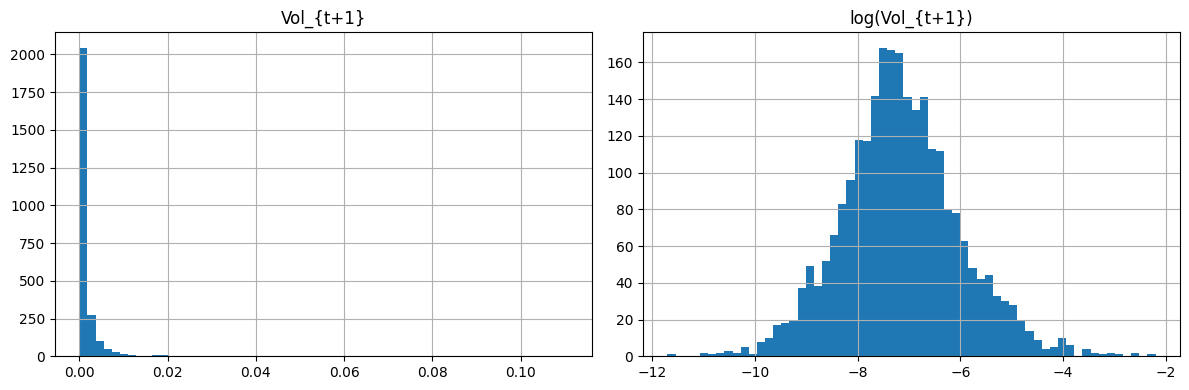

,count,mean,std,min,25%,50%,75%,max
mentions,2555.0,62681.351859,31446.951347,9047.000000,40777.500000,52917.000000,81872.500000,297382.000000
buzz,2555.0,200387.255871,73886.083880,33122.100000,155795.050000,192535.000000,232767.650000,918953.500000
sentiment,2555.0,0.009573,0.048543,-0.261684,-0.019657,0.015734,0.042047,0.182279
negative,2555.0,0.213169,0.024251,0.136728,0.197197,0.210189,0.227334,0.398868
positive,2555.0,0.222742,0.025333,0.125204,0.207266,0.225813,0.239563,0.319007
optimism,2555.0,0.064774,0.011335,0.033059,0.057492,0.063538,0.070977,0.138076
pessimism,2555.0,0.053841,0.005688,0.037093,0.049710,0.053523,0.057445,0.075656
joy,2555.0,0.007877,0.001555,0.003910,0.006923,0.007737,0.008715,0.020148
loveHate,2555.0,0.003058,0.000702,0.000407,0.002598,0.003044,0.003491,0.009946
trust,2555.0,0.004936,0.004633,-0.058269,0.002404,0.004934,0.007603,0.026430


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df['Vol_next'].hist(bins=60, ax=ax[0]); ax[0].set_title('Vol_{t+1}')
np.log(df.loc[df['Vol_next'] > 0, 'Vol_next']).hist(bins=60, ax=ax[1])
ax[1].set_title('log(Vol_{t+1})')
plt.tight_layout(); plt.show()
df[feature_cols + ['Vol_next']].describe().T

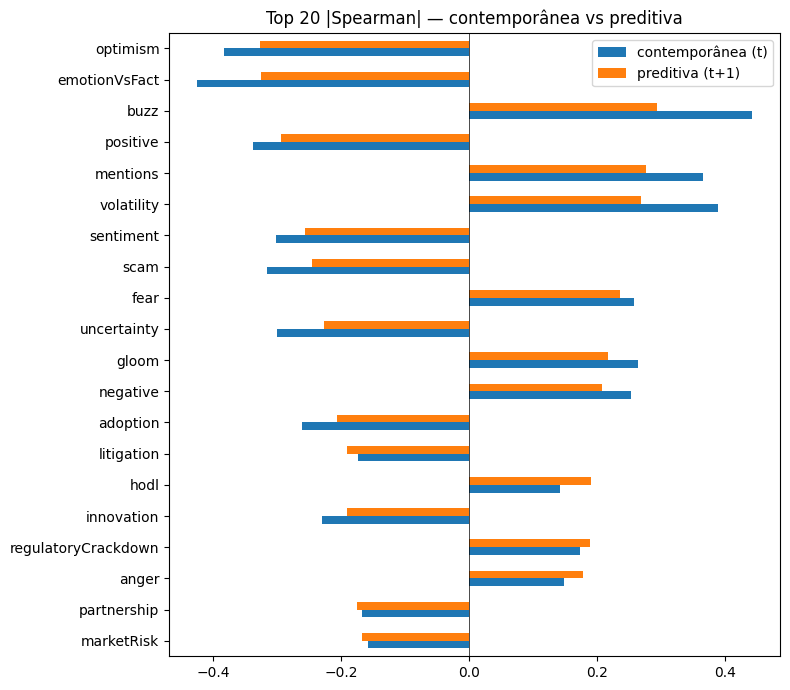

,contemporânea (t),preditiva (t+1)
optimism,-0.383680,-0.327569
emotionVsFact,-0.425553,-0.325140
buzz,0.443027,0.294544
positive,-0.338669,-0.293981
mentions,0.366277,0.277346
volatility,0.389539,0.268871
sentiment,-0.302424,-0.255871
scam,-0.315714,-0.246323
fear,0.257742,0.236256
uncertainty,-0.300431,-0.226265


In [9]:
# Spearman de cada feature com a volatilidade — contemporânea (t) e preditiva (t+1)
ALVOS = {'contemporânea (t)': 'Vol', 'preditiva (t+1)': 'Vol_next'}
corr = pd.DataFrame({
    nome: {c: spearmanr(df[c], df[col])[0] for c in feature_cols}
    for nome, col in ALVOS.items()
})
# ordena pelo |Spearman| da preditiva
corr_ord = corr.reindex(corr['preditiva (t+1)'].abs().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(8, 7))
corr_ord.head(20).iloc[::-1].plot.barh(ax=ax)
ax.axvline(0, c='k', lw=.5)
ax.set_title('Top 20 |Spearman| — contemporânea vs preditiva')
plt.tight_layout(); plt.show()
corr_ord.head(20)

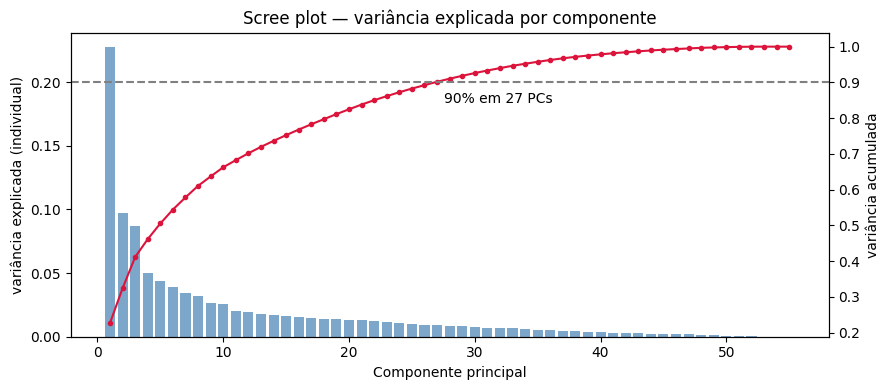

PC1: 22.7% | PC1+PC2: 32.4% | 90% em 27 de 55 PCs


In [10]:
# PCA — APENAS exploração (não alimenta o modelo de importância)
X_std = StandardScaler().fit_transform(df[feature_cols])
pca = PCA().fit(X_std)
var_ind = pca.explained_variance_ratio_          # variância de cada PC
var_cum = np.cumsum(var_ind)                      # variância acumulada
n90 = int(np.argmax(var_cum >= 0.9) + 1)          # PCs para atingir 90%

# --- Gráfico explained_variance: barras (individual) + linha (acumulada) ---
fig, ax1 = plt.subplots(figsize=(9, 4))
x = np.arange(1, len(var_ind) + 1)
ax1.bar(x, var_ind, color='steelblue', alpha=.7, label='individual')
ax1.set_xlabel('Componente principal'); ax1.set_ylabel('variância explicada (individual)')

ax2 = ax1.twinx()
ax2.plot(x, var_cum, color='crimson', marker='.', label='acumulada')
ax2.axhline(0.9, ls='--', c='gray'); ax2.set_ylabel('variância acumulada')
ax2.annotate(f'90% em {n90} PCs', (n90, 0.9), textcoords='offset points', xytext=(5, -15))
ax1.set_title('Scree plot — variância explicada por componente')
fig.tight_layout(); plt.show()

print(f'PC1: {var_ind[0]:.1%} | PC1+PC2: {var_cum[1]:.1%} | 90% em {n90} de {len(var_ind)} PCs')

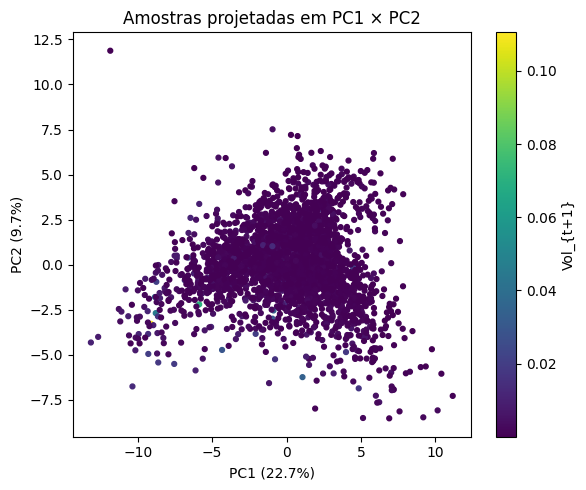

Features que mais definem PC1:
sentiment         0.271099
negative          0.268341
positive          0.262608
marketRisk        0.259736
gloom             0.244482
priceDirection    0.239396
priceMomentum     0.233032
priceForecast     0.222011
Name: PC1, dtype: float64

Features que mais definem PC2:
adoption         0.270326
futureVsPast     0.242661
priceUp          0.237740
emotionVsFact    0.237197
volatility       0.219251
buzz             0.214188
surprise         0.212906
joy              0.212567
Name: PC2, dtype: float64


In [11]:
# Projeção PC1×PC2 colorida pela vol + loadings (o que cada PC representa)
pcs = pca.transform(X_std)
fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(pcs[:, 0], pcs[:, 1], c=df['Vol_next'], cmap='viridis', s=12)
ax.set_xlabel(f'PC1 ({var_ind[0]:.1%})'); ax.set_ylabel(f'PC2 ({var_ind[1]:.1%})')
ax.set_title('Amostras projetadas em PC1 × PC2')
plt.colorbar(sc, ax=ax, label='Vol_{t+1}'); plt.tight_layout(); plt.show()

# Loadings: peso de cada feature nos 2 primeiros PCs (interpretação dos eixos)
loadings = pd.DataFrame(pca.components_[:2].T, index=feature_cols, columns=['PC1', 'PC2'])
print('Features que mais definem PC1:')
print(loadings['PC1'].abs().sort_values(ascending=False).head(8))
print('\nFeatures que mais definem PC2:')
print(loadings['PC2'].abs().sort_values(ascending=False).head(8))

## Etapa 5 - Medir a importância das features com Random Forest

Aqui treino um Random Forest nas **features originais**, porque o objetivo é dizer *qual índice de sentimento* importa

Três escolhas que valem explicar:

- **Alvo em `log(Vol)`.** A volatilidade tem cauda pesada; sem o `log`, um punhado de dias extremos domina o erro e o R² fica muito negativo. Reporto o R² nessa escala log e também o erro (RMSE/MAE) na escala original, mais fácil de ler.
- **Treino e teste em ordem cronológica**, usando o mesmo corte da Etapa 3. Em série temporal não dá para embaralhar: o teste tem que ser o futuro do treino.
- **Importância por permutação**, medida no teste. Ela embaralha uma feature de cada vez e vê o quanto o erro piora. Mais confiável que a importância padrão quando as features são correlacionadas.

E, de novo, comparo os dois horizontes lado a lado: contemporâneo (`Vol`) e preditivo (`Vol_next`).

In [12]:
# Alvo log-transformado + split temporal (CORTE da Etapa 3). RF não precisa de escala.
def avaliar_rf(col, n_estimators=400):
    y = np.log(df[col].values)
    X = df[feature_cols].values
    X_tr, X_te = X[:CORTE], X[CORTE:]
    y_tr, y_te = y[:CORTE], y[CORTE:]

    rf = RandomForestRegressor(n_estimators=n_estimators, random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    pred = rf.predict(X_te)

    met = {'R2_log': round(r2_score(y_te, pred), 4)}
    orig = calcular_metricas_regressao(np.exp(y_te), np.exp(pred))
    met['RMSE_orig'] = round(orig['RMSE'], 6)
    met['MAE_orig'] = round(orig['MAE'], 6)

    perm = permutation_importance(rf, X_te, y_te, n_repeats=20, random_state=42, n_jobs=-1)
    imp = pd.Series(perm.importances_mean, index=feature_cols)
    return rf, met, imp


resultados = {}
for nome, col in {'contemporânea (t)': 'Vol', 'preditiva (t+1)': 'Vol_next'}.items():
    rf, met, imp = avaliar_rf(col)
    resultados[nome] = {'rf': rf, 'metricas': met, 'imp': imp}
    print(f'{nome:18s} -> {met}')

pd.DataFrame({n: r['metricas'] for n, r in resultados.items()}).T

contemporânea (t)  -> {'R2_log': 0.0453, 'RMSE_orig': 0.000947, 'MAE_orig': 0.000522}
preditiva (t+1)    -> {'R2_log': -0.2943, 'RMSE_orig': 0.001001, 'MAE_orig': 0.000563}


,R2_log,RMSE_orig,MAE_orig
contemporânea (t),0.0453,0.000947,0.000522
preditiva (t+1),-0.2943,0.001001,0.000563


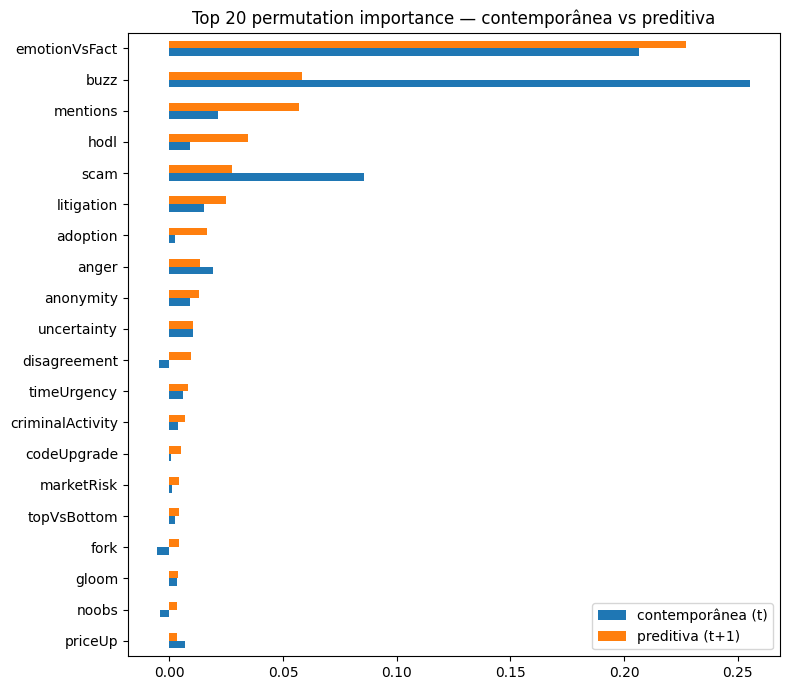

,contemporânea (t),preditiva (t+1)
emotionVsFact,0.206635,0.227227
buzz,0.255528,0.058294
mentions,0.021284,0.057045
hodl,0.009207,0.034744
scam,0.085514,0.027432
litigation,0.015367,0.025105
adoption,0.002694,0.016540
anger,0.019096,0.013728
anonymity,0.009166,0.012867
uncertainty,0.010484,0.010324


In [13]:
# Permutation importance (teste) — contemporânea vs preditiva
imp_df = pd.DataFrame({n: r['imp'] for n, r in resultados.items()})
imp_ord = imp_df.reindex(imp_df['preditiva (t+1)'].sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(8, 7))
imp_ord.head(20).iloc[::-1].plot.barh(ax=ax)
ax.set_title('Top 20 permutation importance — contemporânea vs preditiva')
plt.tight_layout(); plt.show()
imp_ord.head(20)

## Conclusão

o sentimento **descreve melhor o presente do que aposta no futuro**. No mesmo dia ele tem alguma ligação com a volatilidade (R² ≈ 0,05), mas sozinho não prevê a volatilidade do dia seguinte — o R² fica negativo, ou seja, pior do que chutar a média. Como sinal isolado, é fraco para previsão.

### O que o PCA mostrou

O PCA foi a parte que mais ajudou a entender os dados. Ele pega os 54 índices e tenta achar poucas combinações que resumam tudo. O primeiro componente sozinho explica só ≈ 23% da variação, e são precisos muitos componentes para chegar a 90%. Traduzindo: os índices **não são repetição uns dos outros**, cada um carrega um pedaço próprio de informação. Isso é importante porque significa que, na hora de escolher features, não dá para ficar só com duas ou três e achar que cobriu o resto.

Mesmo assim, dá para ler o que cada eixo representa:

- **1º componente - humor do mercado:** puxado por `sentiment`, `negative`, `positive`, `gloom` e `marketRisk`. É o eixo "o mercado está otimista ou com medo/pessimista".
- **2º componente - expectativa e adoção:** puxado por índices ligados a futuro e adoção. É o eixo "o que o mercado espera daqui pra frente".

Ou seja: de um lado o *humor* de agora, do outro a *expectativa* do que vem. São informações diferentes, e vale ter as duas.

### Features com mais potencial para o transformer

Juntando as três pistas: importância no Random Forest, correlação de Spearman e os pesos do PCA. As features que mais valem levar para o modelo de previsão de volatilidade são:

1. **Volume de atenção - `buzz` e `mentions`.** Foram as mais fortes de todas. Medem o *quanto* o mercado fala, e dia de muita conversa costuma ser dia agitado. É o sinal mais robusto que apareceu.
2. **Humor do mercado - `sentiment`, `negative`, `marketRisk`, `gloom`.** Lideram o 1º componente do PCA e aparecem bem no ranking. Capturam medo e pessimismo, que andam junto com volatilidade.
3. **Expectativa - os índices que formam o 2º componente.** Trazem informação diferente das anteriores, por isso entram como complemento, não como substituto.

### Próximo passo

Levar esse núcleo de features para o transformer **junto com o passado da própria volatilidade**, e checar se o sentimento ainda acrescenta alguma coisa além do que a `Vol` passada já explica.